# RAMS Benchmark and Inference on Custom TIFF Scenes

This notebook benchmarks **Nearest**, **Bicubic**, and **RAMS** on scenes where each scene folder contains LR TIFF files and one HR TIFF ground truth.

Expected layout:
- `SCENES_ROOT/scene_name/*.tif` (or `.tiff`)
- Each scene folder should contain LR images and one HR image
- If your dataset is a single folder with TIFF files, the notebook will treat it as one scene

In [1]:
import os
import sys
import numpy as np
import tifffile
import tensorflow as tf
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

print('TensorFlow:', tf.__version__)

TensorFlow: 2.14.1


In [2]:
# -----------------------------
# User configuration
# -----------------------------
REPO_ROOT = os.path.abspath('.')
SCENES_ROOT = os.path.join(REPO_ROOT, 'D:\\GUC\\Datasets\\Rams Test')  # <-- change this

# Number of scenes/images to benchmark. Use None to run all discovered scenes.
MAX_SCENES = None  # e.g. 231 to cap, or None for all

# RAMS expects 9 temporal frames by default
T = 9
LR_SIZE = 128
SCALE = 3
HR_SIZE = LR_SIZE * SCALE

# RAMS architecture settings from repo notebooks
FILTERS = 32
KERNEL_SIZE = 3
R = 8
N = 12

# Comparison controls (no training, inference only)
RAMS_ALIGN_TO_PROBAV = False
DEFAULT_POSTPROCESS = 'match_bicubic_stats'  # options: 'none', 'match_bicubic_stats'

# Define one or more checkpoints to compare in the same run.
# Add more entries to compare other trained models.
BENCHMARK_MODELS = [
    {
        'name': 'NIR_RAMS',
        'checkpoint_dir': os.path.join(REPO_ROOT, 'ckpt', 'NIR_RAMS'),
        'postprocess': DEFAULT_POSTPROCESS,
    },
    {
        'name': 'RED_RAMS',
        'checkpoint_dir': os.path.join(REPO_ROOT, 'ckpt', 'RED_RAMS'),
        'postprocess': DEFAULT_POSTPROCESS,
    },
]

# Output folder for SR TIFF files
OUTPUT_DIR = os.path.join(REPO_ROOT, 'benchmark_outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

assert os.path.isdir(SCENES_ROOT), f'SCENES_ROOT not found: {SCENES_ROOT}'
print('SCENES_ROOT:', SCENES_ROOT)
print('MAX_SCENES:', MAX_SCENES if MAX_SCENES is not None else 'all')
print('Configured benchmark models:')
for spec in BENCHMARK_MODELS:
    print(f"  - {spec['name']}: {spec['checkpoint_dir']} | postprocess={spec.get('postprocess', DEFAULT_POSTPROCESS)}")

SCENES_ROOT: D:\GUC\Datasets\Rams Test
MAX_SCENES: all
Configured benchmark models:
  - NIR_RAMS: d:\GUC\Rams model\RAMS\ckpt\NIR_RAMS | postprocess=match_bicubic_stats
  - RED_RAMS: d:\GUC\Rams model\RAMS\ckpt\RED_RAMS | postprocess=match_bicubic_stats


In [3]:
# -----------------------------
# Build/load RAMS models for benchmarking
# -----------------------------
sys.path.insert(0, REPO_ROOT)
from utils.network import RAMS

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

def load_rams_checkpoint(checkpoint_dir):
    model_local = RAMS(scale=SCALE, filters=FILTERS, kernel_size=KERNEL_SIZE, channels=T, r=R, N=N)
    latest = tf.train.latest_checkpoint(checkpoint_dir)
    if latest is None:
        raise FileNotFoundError(f'No checkpoint found in: {checkpoint_dir}')

    ckpt = tf.train.Checkpoint(step=tf.Variable(0), psnr=tf.Variable(1.0), model=model_local)
    ckpt.restore(latest).expect_partial()
    return model_local, latest

benchmark_models = []
for spec in BENCHMARK_MODELS:
    model_loaded, latest_path = load_rams_checkpoint(spec['checkpoint_dir'])
    benchmark_models.append({
        'name': spec['name'],
        'postprocess': spec.get('postprocess', DEFAULT_POSTPROCESS),
        'checkpoint_dir': spec['checkpoint_dir'],
        'checkpoint': latest_path,
        'model': model_loaded,
    })
    print(f"Loaded {spec['name']} from: {latest_path}")

# Keep `model` for compatibility with downstream debug/diagnostic cells.
model = benchmark_models[0]['model']

d:\GUC\Rams model\RAMS\.venv\Lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


Loaded NIR_RAMS from: d:\GUC\Rams model\RAMS\ckpt\NIR_RAMS\ckpt-71
Loaded RED_RAMS from: d:\GUC\Rams model\RAMS\ckpt\RED_RAMS\ckpt-93


In [4]:
# -----------------------------
# Data and metric helpers
# -----------------------------
def normalize01(img):
    img = img.astype(np.float32)
    mn = float(np.min(img))
    mx = float(np.max(img))
    return (img - mn) / (mx - mn + 1e-8)

def read_tiff_2d(path):
    img = tifffile.imread(path).astype(np.float32)
    if img.ndim > 2:
        img = img[..., 0]
    return img

def scene_tiff_files(scene_path):
    files = [f for f in os.listdir(scene_path) if f.lower().endswith(('.tif', '.tiff'))]
    return sorted(files)

def _extract_lr_index(name):
    base = os.path.splitext(name)[0].lower()
    if not base.startswith('lr_'):
        return 10**9
    tail = base.split('lr_', 1)[1]
    try:
        return int(tail)
    except ValueError:
        return 10**9

def detect_hr_and_lr(scene_path):
    files = scene_tiff_files(scene_path)
    if len(files) < 2:
        raise ValueError(f'Need at least 2 TIFF files in scene: {scene_path}')

    hr_candidates = [f for f in files if os.path.splitext(f)[0].lower() == 'hr']
    lr_candidates = [f for f in files if os.path.splitext(f)[0].lower().startswith('lr_')]
    if hr_candidates and lr_candidates:
        hr_file = sorted(hr_candidates)[0]
        lr_files = sorted(lr_candidates, key=_extract_lr_index)
        return hr_file, lr_files

    hr_name_keywords = ('hr', 'gt', 'target', 'truth', 'label')
    named_hr = [f for f in files if any(k in f.lower() for k in hr_name_keywords)]
    if named_hr:
        hr_file = sorted(named_hr)[0]
        lr_files = sorted([f for f in files if f != hr_file], key=_extract_lr_index)
        return hr_file, lr_files

    shapes = {}
    for f in files:
        img = read_tiff_2d(os.path.join(scene_path, f))
        shapes[f] = img.shape[0] * img.shape[1]

    hr_file = max(shapes, key=shapes.get)
    lr_files = sorted([f for f in files if f != hr_file], key=_extract_lr_index)
    return hr_file, lr_files

def discover_scenes(root):
    subdirs = [
        os.path.join(root, d)
        for d in sorted(os.listdir(root))
        if os.path.isdir(os.path.join(root, d))
    ]
    subdirs = [d for d in subdirs if len(scene_tiff_files(d)) > 0]
    if subdirs:
        return subdirs

    if len(scene_tiff_files(root)) > 0:
        return [root]

    raise ValueError(f'No scene TIFF files found under: {root}')

def resize_2d(img, h, w, method='bilinear'):
    x = tf.convert_to_tensor(img[..., None], dtype=tf.float32)
    y = tf.image.resize(x, [h, w], method=method)
    return y.numpy()[..., 0]

def prepare_lr_tensor(lr_paths, n_frames=T, spatial_size=LR_SIZE, align_to_probav=False, target_mean=7433.6436):
    lr_basenames = [os.path.splitext(os.path.basename(p))[0].lower() for p in lr_paths]
    if len(lr_paths) > 0 and all(name.startswith('lr_') for name in lr_basenames):
        if len(lr_paths) != n_frames:
            raise ValueError(f'Expected exactly {n_frames} LR_*.tiff frames, found {len(lr_paths)} in scene.')

    lr_imgs = [read_tiff_2d(p) for p in lr_paths]

    lr_imgs = lr_imgs[:n_frames]
    if len(lr_imgs) == 0:
        raise ValueError('No LR frames available in scene.')
    while len(lr_imgs) < n_frames:
        lr_imgs.append(lr_imgs[-1])

    lr_resized = [resize_2d(im, spatial_size, spatial_size, method='bilinear') for im in lr_imgs]
    x = np.stack(lr_resized, axis=-1)[None, ...].astype(np.float32)

    scale_factor = 1.0
    if align_to_probav:
        x_mean = float(np.mean(x))
        if x_mean > 0 and x_mean < 2000:
            scale_factor = target_mean / (x_mean + 1e-8)
            x = x * scale_factor

    return x, lr_resized, scale_factor

def normalize_pair_for_metrics(ref, pred):
    ref = ref.astype(np.float32)
    pred = pred.astype(np.float32)
    mn = float(np.min(ref))
    mx = float(np.max(ref))
    dr = max(mx - mn, 1e-8)
    ref_n = np.clip((ref - mn) / dr, 0.0, 1.0)
    pred_n = np.clip((pred - mn) / dr, 0.0, 1.0)
    return ref_n, pred_n

def match_mean_std(src, ref):
    src = src.astype(np.float32)
    ref = ref.astype(np.float32)
    src_m, src_s = float(np.mean(src)), float(np.std(src))
    ref_m, ref_s = float(np.mean(ref)), float(np.std(ref))
    if src_s < 1e-8:
        return np.full_like(src, ref_m, dtype=np.float32)
    out = (src - src_m) * (ref_s / (src_s + 1e-8)) + ref_m
    return out.astype(np.float32)

def safe_ssim(a, b, data_range=1.0):
    try:
        return ssim(a, b, data_range=data_range)
    except TypeError:
        return ssim(a, b, data_range=data_range, channel_axis=None)

In [5]:
# -----------------------------
# Run benchmark (multi-model)
# -----------------------------
print("\n" + "=" * 70)
print("MULTI-IMAGE BENCHMARK (RAMS models vs Nearest/Bicubic)")
print("=" * 70)

scene_paths = discover_scenes(SCENES_ROOT)
if MAX_SCENES is not None:
    scene_paths = scene_paths[:MAX_SCENES]

print('Discovered scenes:', len(scene_paths))
print('Models to evaluate:', [m['name'] for m in benchmark_models])

rows = []
visual_cache = {}

for scene_idx, scene_path in enumerate(scene_paths, start=1):
    scene_name = os.path.basename(scene_path.rstrip(os.sep))
    hr_file, lr_files = detect_hr_and_lr(scene_path)

    lr_paths = [os.path.join(scene_path, f) for f in lr_files]
    hr_path = os.path.join(scene_path, hr_file)

    x, lr_resized, scale_factor = prepare_lr_tensor(
        lr_paths,
        n_frames=T,
        spatial_size=LR_SIZE,
        align_to_probav=RAMS_ALIGN_TO_PROBAV,
    )
    n_real_lr = min(len(lr_paths), T)

    # Baselines from mean LR frame at model LR size.
    lr_mean = np.mean(np.stack(lr_resized[:n_real_lr], axis=0), axis=0)
    nearest_raw = resize_2d(lr_mean, HR_SIZE, HR_SIZE, method='nearest')
    bicubic_raw = resize_2d(lr_mean, HR_SIZE, HR_SIZE, method='bicubic')

    # Ground truth at native size.
    hr_native = read_tiff_2d(hr_path)
    h_hr, w_hr = hr_native.shape

    # Evaluate baselines at native HR resolution.
    nearest_eval = resize_2d(nearest_raw, h_hr, w_hr, method='nearest')
    bicubic_eval = resize_2d(bicubic_raw, h_hr, w_hr, method='bicubic')

    hr_n, nearest_n = normalize_pair_for_metrics(hr_native, nearest_eval)
    _, bicubic_n = normalize_pair_for_metrics(hr_native, bicubic_eval)

    p_nearest = psnr(hr_n, nearest_n, data_range=1.0)
    s_nearest = safe_ssim(hr_n, nearest_n, data_range=1.0)
    p_bicubic = psnr(hr_n, bicubic_n, data_range=1.0)
    s_bicubic = safe_ssim(hr_n, bicubic_n, data_range=1.0)

    for m in benchmark_models:
        model_name = m['name']
        postprocess_mode = m['postprocess']
        model_obj = m['model']

        # RAMS forward pass (network internally upsamples by x3 from 128 -> 384).
        sr_raw = model_obj(x, training=False).numpy()[0, ..., 0]

        # Evaluate RAMS at native HR resolution.
        rams_eval_raw = resize_2d(sr_raw, h_hr, w_hr, method='bicubic')
        if postprocess_mode == 'match_bicubic_stats':
            rams_eval = match_mean_std(rams_eval_raw, bicubic_eval)
        else:
            rams_eval = rams_eval_raw

        _, rams_n = normalize_pair_for_metrics(hr_native, rams_eval)
        _, rams_raw_n = normalize_pair_for_metrics(hr_native, rams_eval_raw)

        p_rams = psnr(hr_n, rams_n, data_range=1.0)
        s_rams = safe_ssim(hr_n, rams_n, data_range=1.0)
        p_rams_raw = psnr(hr_n, rams_raw_n, data_range=1.0)
        s_rams_raw = safe_ssim(hr_n, rams_raw_n, data_range=1.0)

        rows.append({
            'scene': scene_name,
            'model': model_name,
            'postprocess': postprocess_mode,
            'n_lr_frames': len(lr_files),
            'native_hr_shape': (int(h_hr), int(w_hr)),
            'rams_raw_shape': (int(sr_raw.shape[0]), int(sr_raw.shape[1])),
            'scale_factor': float(scale_factor),
            'PSNR_nearest': float(p_nearest),
            'SSIM_nearest': float(s_nearest),
            'PSNR_bicubic': float(p_bicubic),
            'SSIM_bicubic': float(s_bicubic),
            'PSNR_RAMS': float(p_rams),
            'SSIM_RAMS': float(s_rams),
            'PSNR_RAMS_raw': float(p_rams_raw),
            'SSIM_RAMS_raw': float(s_rams_raw),
            'delta_psnr_vs_bicubic': float(p_rams - p_bicubic),
            'delta_ssim_vs_bicubic': float(s_rams - s_bicubic),
        })

        visual_cache[(scene_name, model_name)] = {
            'nearest': nearest_n,
            'bicubic': bicubic_n,
            'rams': rams_n,
            'rams_raw': rams_raw_n,
            'hr': hr_n,
        }

        model_out_dir = os.path.join(OUTPUT_DIR, model_name)
        os.makedirs(model_out_dir, exist_ok=True)
        out_path = os.path.join(model_out_dir, f'rams_output_{scene_name}.tiff')
        tifffile.imwrite(out_path, sr_raw.astype(np.float32))

    print(f"[{scene_idx:>3}/{len(scene_paths)}] Processed scene: {scene_name}")

print('Benchmark complete. Saved RAMS outputs in:', OUTPUT_DIR)
print('Total rows:', len(rows))
print("=" * 70)


MULTI-IMAGE BENCHMARK (RAMS models vs Nearest/Bicubic)
Discovered scenes: 232
Models to evaluate: ['NIR_RAMS', 'RED_RAMS']
[  1/232] Processed scene: image_0000
[  2/232] Processed scene: image_0001
[  3/232] Processed scene: image_0002
[  4/232] Processed scene: image_0003
[  5/232] Processed scene: image_0004
[  6/232] Processed scene: image_0005
[  7/232] Processed scene: image_0006
[  8/232] Processed scene: image_0007
[  9/232] Processed scene: image_0008
[ 10/232] Processed scene: image_0009
[ 11/232] Processed scene: image_0010
[ 12/232] Processed scene: image_0011
[ 13/232] Processed scene: image_0012
[ 14/232] Processed scene: image_0013
[ 15/232] Processed scene: image_0014
[ 16/232] Processed scene: image_0015
[ 17/232] Processed scene: image_0016
[ 18/232] Processed scene: image_0017
[ 19/232] Processed scene: image_0018
[ 20/232] Processed scene: image_0019
[ 21/232] Processed scene: image_0020
[ 22/232] Processed scene: image_0021
[ 23/232] Processed scene: image_0022
[ 

In [6]:
# -----------------------------
# Diagnostics: intensity ranges (first scene, first model)
# -----------------------------
if len(rows) > 0:
    first_scene = rows[0]['scene']
    first_model_name = rows[0]['model']
    first_model_cfg = [m for m in benchmark_models if m['name'] == first_model_name][0]
    first_model = first_model_cfg['model']

    scene_path = [p for p in scene_paths if os.path.basename(p.rstrip(os.sep)) == first_scene][0]
    hr_file, lr_files = detect_hr_and_lr(scene_path)

    lr_paths = [os.path.join(scene_path, f) for f in lr_files]
    hr_path = os.path.join(scene_path, hr_file)

    lr_raw = read_tiff_2d(lr_paths[0])
    hr_raw = read_tiff_2d(hr_path)

    x_dbg, _, sf_dbg = prepare_lr_tensor(
        lr_paths,
        n_frames=T,
        spatial_size=LR_SIZE,
        align_to_probav=RAMS_ALIGN_TO_PROBAV,
    )
    sr_dbg = first_model(x_dbg, training=False).numpy()[0, ..., 0]

    print('Scene:', first_scene)
    print('Model:', first_model_name)
    print('LR[0] min/max:', float(np.min(lr_raw)), float(np.max(lr_raw)))
    print('HR    min/max:', float(np.min(hr_raw)), float(np.max(hr_raw)))
    print('RAMS raw min/max:', float(np.min(sr_dbg)), float(np.max(sr_dbg)))
    print('Input scale factor used:', float(sf_dbg))
    print('Postprocess mode:', first_model_cfg['postprocess'])

Scene: image_0000
Model: NIR_RAMS
LR[0] min/max: 63.0 238.0
HR    min/max: 53.0 247.0
RAMS raw min/max: -520.42041015625 413.91015625
Input scale factor used: 1.0
Postprocess mode: match_bicubic_stats


In [7]:
# -----------------------------
# Summary tables (per-scene + per-model means)
# -----------------------------
import csv

if len(rows) == 0:
    raise RuntimeError('No scenes were processed. Check SCENES_ROOT and file naming.')

all_models = sorted({r['model'] for r in rows})
all_scenes = sorted({r['scene'] for r in rows})

print(f"Total evaluated rows: {len(rows)}")
print(f"Scenes: {len(all_scenes)} | Models: {len(all_models)}")

model_summary_rows = []
for model_name in all_models:
    model_rows = [r for r in rows if r['model'] == model_name]
    d_psnr = [r['delta_psnr_vs_bicubic'] for r in model_rows]
    d_ssim = [r['delta_ssim_vs_bicubic'] for r in model_rows]

    summary = {
        'model': model_name,
        'samples': len(model_rows),
        'mean_psnr_rams': float(np.mean([r['PSNR_RAMS'] for r in model_rows])),
        'mean_ssim_rams': float(np.mean([r['SSIM_RAMS'] for r in model_rows])),
        'mean_psnr_bicubic': float(np.mean([r['PSNR_bicubic'] for r in model_rows])),
        'mean_ssim_bicubic': float(np.mean([r['SSIM_bicubic'] for r in model_rows])),
        'mean_delta_psnr_vs_bicubic': float(np.mean(d_psnr)),
        'mean_delta_ssim_vs_bicubic': float(np.mean(d_ssim)),
        'median_delta_psnr_vs_bicubic': float(np.median(d_psnr)),
        'median_delta_ssim_vs_bicubic': float(np.median(d_ssim)),
    }
    model_summary_rows.append(summary)

model_summary_rows = sorted(model_summary_rows, key=lambda x: x['mean_psnr_rams'], reverse=True)

print('\nPer-model mean metrics:')
for s in model_summary_rows:
    print(
        f"{s['model']:<20} | n={s['samples']:<4} | "
        f"PSNR(RAMS)={s['mean_psnr_rams']:.3f} | SSIM(RAMS)={s['mean_ssim_rams']:.5f} | "
        f"dPSNR vs Bicubic={s['mean_delta_psnr_vs_bicubic']:.3f} | "
        f"dSSIM vs Bicubic={s['mean_delta_ssim_vs_bicubic']:.5f}"
    )

if len(all_models) >= 2:
    print('\nPairwise model mean differences (A - B):')
    pairwise_rows = []
    for i, model_a in enumerate(all_models):
        for model_b in all_models[i + 1:]:
            scene_to_a = {r['scene']: r for r in rows if r['model'] == model_a}
            scene_to_b = {r['scene']: r for r in rows if r['model'] == model_b}
            shared_scenes = sorted(set(scene_to_a.keys()) & set(scene_to_b.keys()))
            if len(shared_scenes) == 0:
                continue

            psnr_diffs = [scene_to_a[s]['PSNR_RAMS'] - scene_to_b[s]['PSNR_RAMS'] for s in shared_scenes]
            ssim_diffs = [scene_to_a[s]['SSIM_RAMS'] - scene_to_b[s]['SSIM_RAMS'] for s in shared_scenes]

            pairwise_rows.append({
                'model_a': model_a,
                'model_b': model_b,
                'shared_scenes': len(shared_scenes),
                'mean_psnr_diff_a_minus_b': float(np.mean(psnr_diffs)),
                'mean_ssim_diff_a_minus_b': float(np.mean(ssim_diffs)),
            })

    for p in sorted(pairwise_rows, key=lambda x: x['mean_psnr_diff_a_minus_b'], reverse=True):
        print(
            f"{p['model_a']} - {p['model_b']} | shared={p['shared_scenes']} | "
            f"dPSNR={p['mean_psnr_diff_a_minus_b']:.4f} | dSSIM={p['mean_ssim_diff_a_minus_b']:.6f}"
        )

benchmark_csv = os.path.join(OUTPUT_DIR, 'benchmark_detailed_multi_model.csv')
summary_csv = os.path.join(OUTPUT_DIR, 'benchmark_summary_multi_model.csv')

detailed_columns = [
    'scene', 'model', 'postprocess', 'n_lr_frames', 'native_hr_shape', 'rams_raw_shape',
    'scale_factor', 'PSNR_nearest', 'SSIM_nearest', 'PSNR_bicubic', 'SSIM_bicubic',
    'PSNR_RAMS', 'SSIM_RAMS', 'PSNR_RAMS_raw', 'SSIM_RAMS_raw',
    'delta_psnr_vs_bicubic', 'delta_ssim_vs_bicubic',
]

with open(benchmark_csv, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=detailed_columns)
    writer.writeheader()
    for r in rows:
        writer.writerow(r)

summary_columns = [
    'model', 'samples', 'mean_psnr_rams', 'mean_ssim_rams',
    'mean_psnr_bicubic', 'mean_ssim_bicubic',
    'mean_delta_psnr_vs_bicubic', 'mean_delta_ssim_vs_bicubic',
    'median_delta_psnr_vs_bicubic', 'median_delta_ssim_vs_bicubic',
]

with open(summary_csv, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=summary_columns)
    writer.writeheader()
    for s in model_summary_rows:
        writer.writerow(s)

print(f"\nSaved detailed benchmark table to: {benchmark_csv}")
print(f"Saved model summary table to: {summary_csv}")

Total evaluated rows: 464
Scenes: 232 | Models: 2

Per-model mean metrics:
NIR_RAMS             | n=232  | PSNR(RAMS)=20.680 | SSIM(RAMS)=0.56679 | dPSNR vs Bicubic=-3.666 | dSSIM vs Bicubic=-0.09319
RED_RAMS             | n=232  | PSNR(RAMS)=19.765 | SSIM(RAMS)=0.48445 | dPSNR vs Bicubic=-4.581 | dSSIM vs Bicubic=-0.17553

Pairwise model mean differences (A - B):
NIR_RAMS - RED_RAMS | shared=232 | dPSNR=0.9149 | dSSIM=0.082340

Saved detailed benchmark table to: d:\GUC\Rams model\RAMS\benchmark_outputs\benchmark_detailed_multi_model.csv
Saved model summary table to: d:\GUC\Rams model\RAMS\benchmark_outputs\benchmark_summary_multi_model.csv


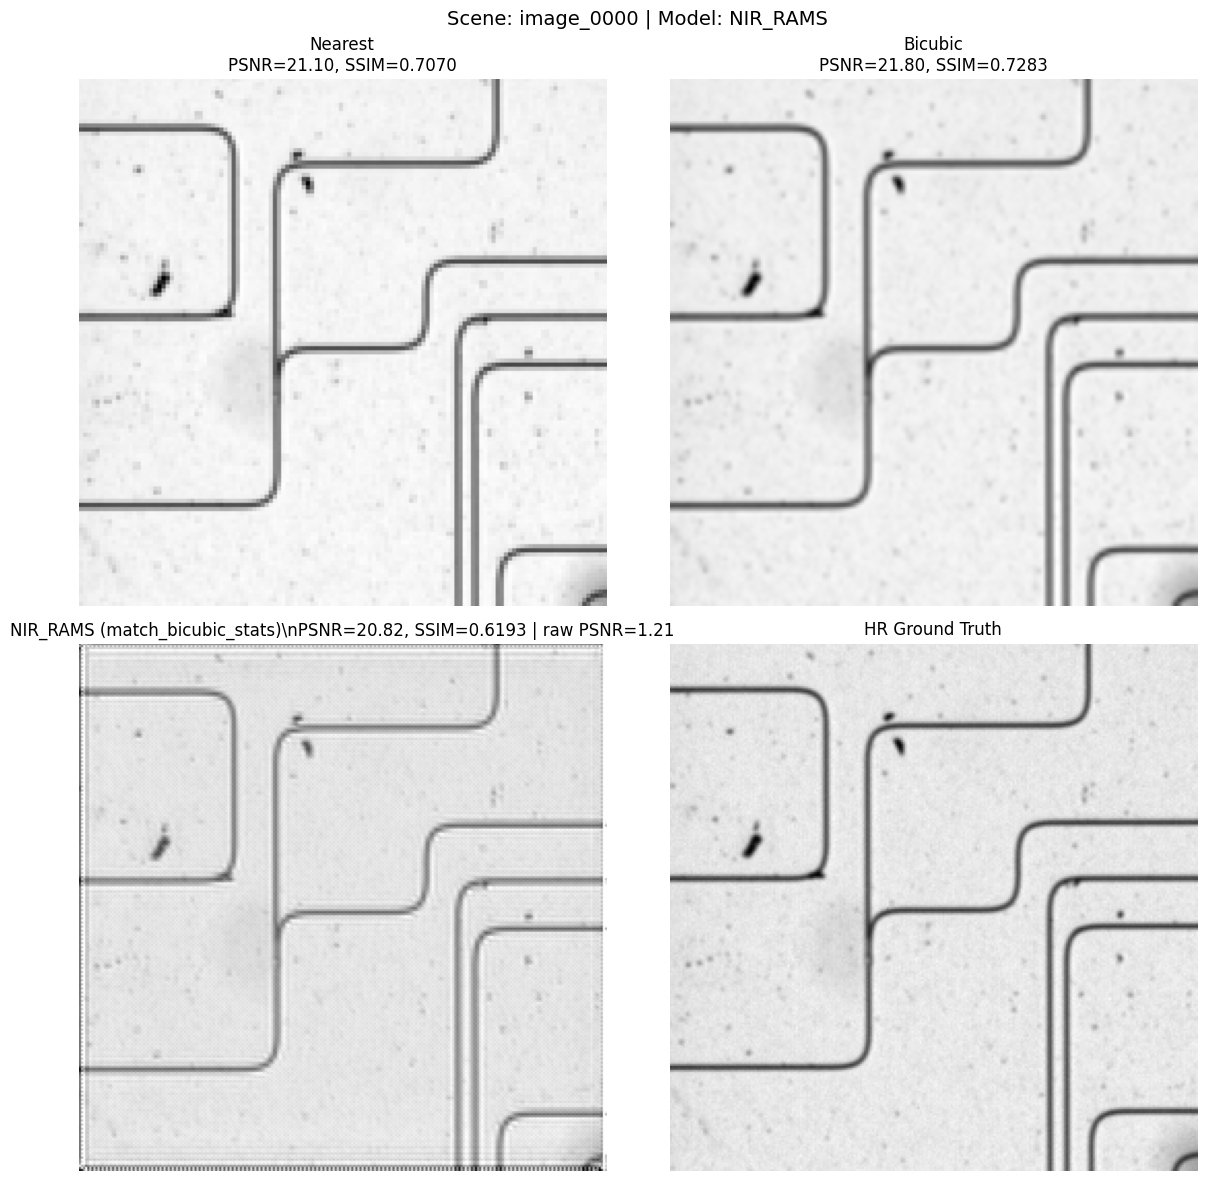

In [8]:
# -----------------------------
# Visual comparison (Nearest / Bicubic / RAMS / HR)
# -----------------------------
scene_to_show = rows[0]['scene']  # change to any processed scene name
model_to_show = rows[0]['model']  # change to any evaluated model name

data = visual_cache[(scene_to_show, model_to_show)]
scene_metrics = [
    r for r in rows
    if r['scene'] == scene_to_show and r['model'] == model_to_show
][0]

# Display normalization only
nearest_disp = normalize01(data['nearest'])
bicubic_disp = normalize01(data['bicubic'])
rams_disp = normalize01(data['rams'])
hr_disp = normalize01(data['hr'])

fig, ax = plt.subplots(2, 2, figsize=(12, 12))

ax[0, 0].imshow(nearest_disp, cmap='gray')
ax[0, 0].set_title(f"Nearest\nPSNR={scene_metrics['PSNR_nearest']:.2f}, SSIM={scene_metrics['SSIM_nearest']:.4f}")
ax[0, 0].axis('off')

ax[0, 1].imshow(bicubic_disp, cmap='gray')
ax[0, 1].set_title(f"Bicubic\nPSNR={scene_metrics['PSNR_bicubic']:.2f}, SSIM={scene_metrics['SSIM_bicubic']:.4f}")
ax[0, 1].axis('off')

ax[1, 0].imshow(rams_disp, cmap='gray')
ax[1, 0].set_title(
    f"{scene_metrics['model']} ({scene_metrics['postprocess']})\\n"
    f"PSNR={scene_metrics['PSNR_RAMS']:.2f}, SSIM={scene_metrics['SSIM_RAMS']:.4f} | "
    f"raw PSNR={scene_metrics['PSNR_RAMS_raw']:.2f}"
)
ax[1, 0].axis('off')

ax[1, 1].imshow(hr_disp, cmap='gray')
ax[1, 1].set_title('HR Ground Truth')
ax[1, 1].axis('off')

plt.suptitle(f'Scene: {scene_to_show} | Model: {model_to_show}', fontsize=14)
plt.tight_layout()
plt.show()